In [3]:
import numpy as np 
import matplotlib.pyplot as plt 
from astropy.io import fits
import muram as mio

In [4]:
# This is a notebook to read the fits files that contain the level populations calculate with lightweaver code and extend them to long cubes. 
# We will perform similar extension / interpolation using MURAM cubes, for which we need a separte reading routines. 

In [5]:
# Check the spectra and level populations:
output = fits.open("/dat/milic/MURaM_enhanced_network/che_full_499000_lwsynth_200.0.fits")
output.info()

Filename: /dat/milic/MURaM_enhanced_network/che_full_499000_lwsynth_200.0.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       8   (1031, 1, 1024, 1024)   float64   
  1                1 ImageHDU         6   (1031,)   float64   
  2                1 ImageHDU         9   (401, 6, 1024, 1024)   float64   


In [7]:
pops = output[2].data
pops.shape

(1024, 1024, 6, 401)

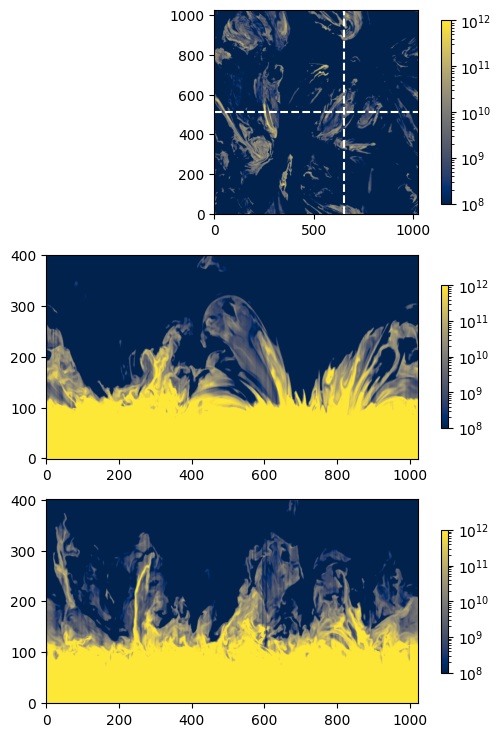

In [9]:
# A few test plots of the pops: 
i_slice = 650
j_slice = 512

plt.figure(figsize=[6,9])

plt.subplot(311)
plt.imshow(pops[:,:,0,160].T, origin="lower", cmap='cividis', norm='log', vmin=1E8, vmax=1E12)
# Add a white line where the slice is taken
plt.axvline(i_slice, color='white', linestyle='--')
plt.axhline(j_slice, color='white', linestyle='--')
plt.colorbar(shrink=0.9)

plt.subplot(312)
plt.imshow(pops[i_slice,:,0,::-1].T, origin="lower", cmap='cividis', norm='log', vmin=1E8, vmax=1E12, aspect='auto')
plt.colorbar(shrink=0.7)

plt.subplot(313)
plt.imshow(pops[:,j_slice,0,::-1].T, origin="lower", cmap='cividis', norm='log', vmin=1E8, vmax=1E12, aspect='auto')
plt.colorbar(shrink=0.7)

### Now the main part : Here we are doing extensions to long slices to be fed in the RT code:

In [28]:
# Let's cut this under a small angle and make use of the periodicity of the data to get a longer slice through the atmosphere
angle = 10  # degrees
angle_rad = np.radians(angle)

# starting point in x 
x_start = 0
y_start = 0

# these are native steps in x and y 
delta_x = 24 # in km
delta_y = 24 # in km

# We want a line that has given length, say - 10ish cubes:
line_length_km = 2E5  # in km

n_steps = int(line_length_km / delta_x)
print("number of steps is: ", n_steps)

number of steps is:  8333


In [29]:
# Get the coordinates of this steps: 
x_coords = x_start + (np.arange(n_steps) + 0.5) * delta_x * np.cos(angle_rad)
y_coords = y_start + (np.arange(n_steps) + 0.5) * delta_y * np.sin(angle_rad)

# Take the module so we know where to take the values from the original cube:
x_coords_in_box = x_coords % ((pops.shape[0]-1)*delta_x)
y_coords_in_box = y_coords % ((pops.shape[1]-1)*delta_y) 

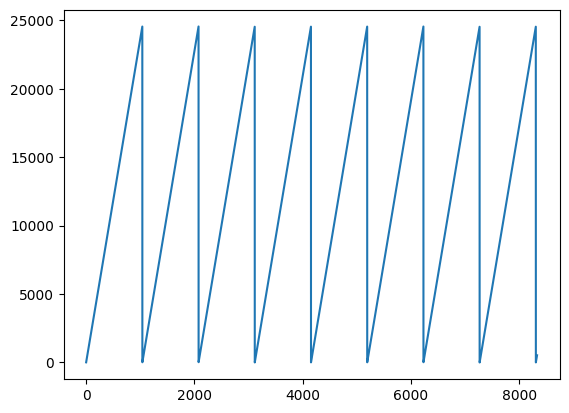

In [30]:
# Quick plot: 
plt.plot(x_coords_in_box)

In [31]:
# For a given z slice, we can now interpolate the population values along this line.
z_slice = 160  # for example, the first z slice

from scipy.interpolate import RegularGridInterpolator
# Interpolator is 2D , and it takes values from the box and then interpolates onto the "long" line, that is folded back into the box.
# Create an interpolator for the population data
interpolator = RegularGridInterpolator((np.arange(pops.shape[0])*delta_x, np.arange(pops.shape[1])*delta_y), pops[:,:,0,z_slice], bounds_error=False, fill_value=np.nan)
# Interpolate along the line
pop_along_line = interpolator(np.array([x_coords_in_box, y_coords_in_box]).T)
# check for Nans: 
if (np.sum(np.isnan(pop_along_line)) > 0):
    print("There are  NaNs in the interpolated population along the line!")
else:
    print("No NaNs in the interpolated population along the line.")


No NaNs in the interpolated population along the line.


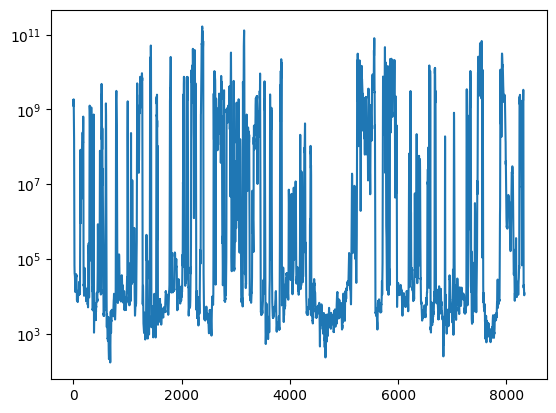

In [32]:
# Now we plot real quick with a little debug:
plt.semilogy(pop_along_line)

In [33]:
from tqdm import tqdm

In [36]:
# Now repeat this process for all z slices and create a long vertical slice:
vertical_slice = np.zeros((n_steps, pops.shape[3]))
for z in tqdm(range(pops.shape[3])):
    interpolator = RegularGridInterpolator((np.arange(pops.shape[0])*delta_x, np.arange(pops.shape[1])*delta_y), pops[:,:,0,z], bounds_error=False, fill_value=np.nan)
    vertical_slice[:,z] = interpolator(np.array([x_coords_in_box, y_coords_in_box]).T)

100%|██████████| 401/401 [00:00<00:00, 1106.59it/s]


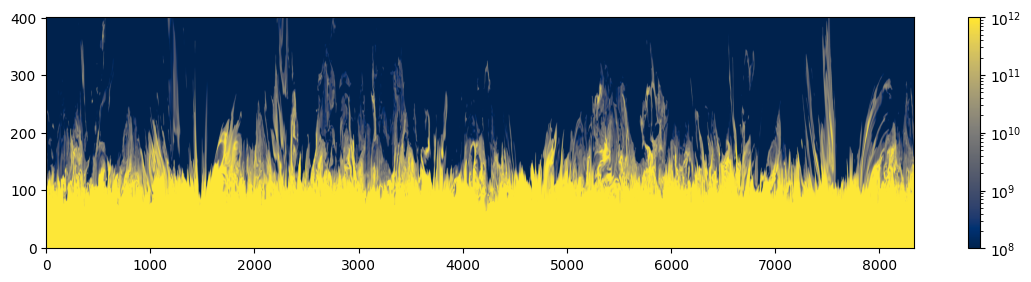

In [39]:
# Now plot this vertical slice:
plt.figure(figsize=[14,3])
plt.imshow(vertical_slice[:,::-1].T, origin="lower", cmap='cividis', norm='log', vmin=1E8, vmax=1E12, aspect='auto')
plt.colorbar()

In [40]:
# Should I pack this all for RT, together with the corresponding temperatures and velocities?
# Probably not the worst idea ever! 